# Ch 13 · Lab 2 — Train/Test Split

원본: `05_Sonar_Train_Test.py`

Lab 1의 함정을 해결: 데이터를 70/30으로 분할해서 *모델이 본 적 없는* 30%로 평가.

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

2026-05-12 16:46:00.706761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778571960.722672 1508614 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778571960.727892 1508614 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터 + 분할

In [2]:
DATA = "../../data/sonar.csv"
df = pd.read_csv(DATA, header=None)
X = df.iloc[:, 0:60].to_numpy(dtype="float32")
y_str = df.iloc[:, 60].to_numpy()
y = LabelEncoder().fit_transform(y_str).astype("float32")
print("X:", X.shape, "y:", y.shape, "분포:", np.bincount(y.astype(int)))


X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print("train:", X_tr.shape, "test:", X_te.shape)

X: (208, 60) y: (208,) 분포: [111  97]
train: (145, 60) test: (63, 60)


> `stratify=y` 추가: 두 클래스 비율을 train/test에서 동일하게 유지 (책에는 없지만 작은 데이터셋에서 권장).

## 2. 모델

In [3]:
def build_model():
    return Sequential([
        Input(shape=(60,)),
        Dense(24, activation="relu"),
        Dense(10, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

keras.utils.set_random_seed(0)
model = build_model()
model.compile(loss="mean_squared_error", optimizer="adam", metrics=["accuracy"])

2026-05-12 16:46:02.968961: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 3. 학습

In [4]:
hist = model.fit(X_tr, y_tr, epochs=130, batch_size=5, verbose=0)

## 4. 평가 — train vs test

In [5]:
tr_loss, tr_acc = model.evaluate(X_tr, y_tr, verbose=0)
te_loss, te_acc = model.evaluate(X_te, y_te, verbose=0)
print(f"train acc = {tr_acc:.4f}")
print(f"test  acc = {te_acc:.4f}")
print(f"gap        = {tr_acc - te_acc:+.4f}  (양수면 과적합 의심)")

train acc = 0.9793
test  acc = 0.8254
gap        = +0.1539  (양수면 과적합 의심)


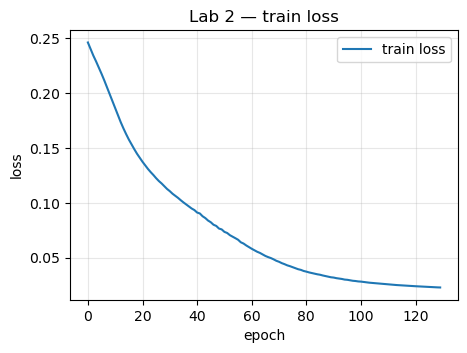

In [6]:
plt.figure(figsize=(5, 3.5))
plt.plot(hist.history["loss"], label="train loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Lab 2 — train loss")
plt.show()